# DistilBERT Transfer Learning on SST-2

A modern PyTorch/Hugging Face version of the original TensorFlow notebook.

**Updates**
- Uses `AutoModelForSequenceClassification` and `Trainer`.
- Uses dynamic padding instead of padding every example to a fixed length.
- Uses the namespaced dataset ID `stanfordnlp/sst2`.
- Freezes the DistilBERT backbone by default, while training the classifier head.
- Uses small configurable subsets so the notebook runs comfortably on a Colab GPU.

Select **Runtime → Change runtime type → T4 GPU** before training.

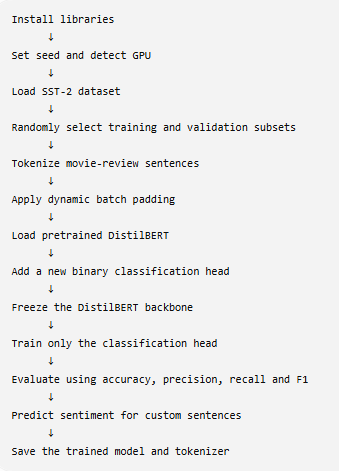

What is genuinely new?

Compared with Codes 1–8 and the earlier inference notebook, these are the main new concepts.

1. Frozen-backbone transfer learning


The previous LoRA approach inserted small trainable adapter matrices into the pretrained model.

Here, no adapters are inserted. The complete Transformer backbone is frozen, and only the existing classification head is trained.

Method--------------Trainable component

Full fine-tuninG----Entire pretrained model

LoRA----------------Small inserted low-rank matrices

This notebook-------Classification head only


The earlier multi-model notebook loaded an already fine-tuned SST-2 classifier:distilbert-base-uncased-finetuned-sst-2-english

This notebook starts from the general pretrained model: distilbert-base-uncased, It then trains its own sentiment-classification head on SST-2.

In [ ]:
# Colab setup for text-only Hugging Face workflows.
# torchao/torchvision/timm are optional here and can conflict with Colab's preinstalled PyTorch.
%pip uninstall -y torchao torchvision timm
%pip install -q -U \
    "transformers>=4.57,<6" \
    "datasets>=4,<5" \
    "accelerate>=1.10,<2" \
    "evaluate>=0.4,<1" \
    "sentencepiece>=0.2,<1" \
    "scikit-learn>=1.5,<2"    #It also removes optional vision-related packages that may conflict with the Colab PyTorch environment.

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: timm 1.0.28
Uninstalling timm-1.0.28:
  Successfully uninstalled timm-1.0.28
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 137.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed

In [ ]:
import os
import random
import numpy as np
import torch
import transformers
import datasets
import accelerate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.14.1
Datasets: 4.8.5
Accelerate: 1.14.0
CUDA available: True


## Load and prepare SST-2

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "distilbert/distilbert-base-uncased"
TRAIN_SAMPLES = 20_000       # Increase for a longer experiment
VALIDATION_SAMPLES = 872

# The notebook randomly selects:

# 20,000 training examples
# 872 validation examples

# The sampling is correctly done by shuffling the complete split before selecting examples

raw_dataset = load_dataset("stanfordnlp/sst2") #SST-2 contains movie-review sentences with two labels: 0 (Negative), 1 (Positive)

train_raw = (
    raw_dataset["train"]
    .shuffle(seed=SEED)
    .select(range(min(TRAIN_SAMPLES, len(raw_dataset["train"]))))
)
validation_raw = (
    raw_dataset["validation"]
    .shuffle(seed=SEED)
    .select(range(min(VALIDATION_SAMPLES, len(raw_dataset["validation"]))))
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        max_length=128,
    )

# Each sentence is converted into:

# input_ids
# attention_mask
# Label

# The original sentence and idx columns are removed after tokenization

train_dataset = train_raw.map(
    tokenize_batch,
    batched=True,
    remove_columns=["sentence", "idx"],
)
validation_dataset = validation_raw.map(
    tokenize_batch,
    batched=True,
    remove_columns=["sentence", "idx"],
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
#Instead of padding every sentence to 128 tokens, it pads each batch only to the longest sentence in that batch. This reduces unnecessary computation.
print(train_dataset)
print(validation_dataset)
print(train_dataset[0])

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 20000
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 872
})
{'label': 1, 'input_ids': [101, 12555, 1010, 11951, 1999, 22092, 2066, 2137, 11345, 1998, 2757, 1011, 2006, 1999, 2602, 1010, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## Load the model and freeze the pretrained backbone

In [ ]:
from transformers import AutoModelForSequenceClassification

id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
# The original distilbert-base-uncased model does not contain a trained SST-2 classifier. Therefore:

# The pretrained language-model backbone is loaded.
# A new classification head is initialized.
# That new head must be trained.

# The missing/unexpected-weight report in the output is expected because the checkpoint and downstream classification architecture are different
# Transfer-learning setup: freeze DistilBERT, train only the classification head.
model.distilbert.requires_grad_(False) #This is the central transfer-learning step. The notebook freezes the approximately 66 million pretrained DistilBERT parameters and trains only: pre_classifier and classifier

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print(f"Trainable percentage: {100 * trainable / total:.4f}%")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 592,130
Total parameters: 66,955,010
Trainable percentage: 0.8844%


To fine-tune the entire model instead, run:

```python
model.distilbert.requires_grad_(True)
```

before creating the trainer.

## Train and evaluate

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, TrainingArguments

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = TrainingArguments(
    output_dir="./distilbert_sst2_output",
    num_train_epochs=2,
    learning_rate=5e-4,  # suitable when only the classifier head is trainable
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=use_fp16,
    bf16=use_bf16,
    report_to="none",
    seed=SEED,
    save_total_limit=1,
)
# The classification head is trained for two epochs using:

# Learning rate: 5e-4
# Training batch size: 32
# Validation batch size: 64
# FP16 or BF16 when supported
# Validation after every epoch
# Checkpoint selection based on F1
# The best checkpoint is loaded automatically at the end.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)
#The helper function:  compute_metrics() converts output logits to predicted classes using: predictions = np.argmax(logits, axis=-1) then calculates Acc, Precision, Recall and F1
trainer.train()
metrics = trainer.evaluate()
metrics

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.364983,0.387996,0.824541,0.818381,0.842342,0.830189
2,0.355043,0.372756,0.834862,0.831858,0.846847,0.839286


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.355043,0.372756,2,0.834862,0.831858,0.846847,0.839286


{'eval_loss': 0.3727555572986603,
 'eval_accuracy': 0.8348623853211009,
 'eval_precision': 0.831858407079646,
 'eval_recall': 0.8468468468468469,
 'eval_f1': 0.8392857142857143}

This means the frozen-backbone classifier correctly classified approximately 83.5% of the validation sentences.

## Test the trained model

In [ ]:
device = next(model.parameters()).device

# This function:

# Tokenizes a new sentence.
# Sends it to the trained model.
# Obtains classification logits.
# Converts logits into probabilities with softmax.
# Chooses the highest-probability class.
# Returns the label and confidence.

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    model.eval()
    with torch.inference_mode():
        logits = model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)[0]
    label_id = int(probabilities.argmax())
    return {
        "label": model.config.id2label[label_id],
        "confidence": float(probabilities[label_id]),
    }

examples = [
    "The film was warm, funny, and beautifully acted.",
    "The plot was dull and the ending made no sense.",
]
for text in examples:
    print(text)
    print(predict_sentiment(text))
    print()

The film was warm, funny, and beautifully acted.
{'label': 'POSITIVE', 'confidence': 0.9987744688987732}

The plot was dull and the ending made no sense.
{'label': 'NEGATIVE', 'confidence': 0.9963500499725342}



## Save the model

In [ ]:
SAVE_DIR = "./distilbert_sst2_transfer_learning"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./distilbert_sst2_transfer_learning


One limitation

The notebook does not evaluate on a separate labelled test set. SST-2’s official test labels are not publicly included, so it uses the validation split for final reported performance.

Also, because the DistilBERT backbone remains frozen, the result is a lightweight transfer-learning baseline. Unfreezing the backbone and fine-tuning with a smaller learning rate would probably improve performance, but would require more GPU memory and training time.